# Q-Learning Tutorial — FrozenLake

**Goal:** Train an agent to solve the [FrozenLake-v1](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) environment using tabular Q-learning.

### Environment overview
```
SFFF       (S=start, F=frozen, H=hole, G=goal)
FHFH
FFFH
HFFG
```
- **States:** 16 (4×4 grid positions)
- **Actions:** 4 (Left=0, Down=1, Right=2, Up=3)
- **Reward:** +1 on reaching goal, 0 otherwise
- **is_slippery=False** to keep it deterministic for learning

### Update rule
$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\Big]$$

## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 2 — Create the Environment

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=True)

n_states  = env.observation_space.n   # 16
n_actions = env.action_space.n        # 4
action_names = ["←", "↓", "→", "↑"]

print(f"States : {n_states}")
print(f"Actions: {n_actions}  {action_names}")

# Show the map
env_render = gym.make("FrozenLake-v1", is_slippery=True, render_mode="ansi")
obs, _ = env_render.reset()
print("\nMap:")
print(env_render.render())

States : 16
Actions: 4  ['←', '↓', '→', '↑']

Map:

SFFF
FHFH
FFFH
HFFG



## 3 — Hyperparameters

| Parameter | Value | Meaning |
|---|---|---|
| α (alpha) | 0.8 | Learning rate — how fast Q-values shift toward new info |
| γ (gamma) | 0.95 | Discount factor — how much future rewards matter |
| ε (epsilon) | 1.0 → 0.01 | Exploration rate — decays over episodes |
| Episodes | 10 000 | Total training episodes |

In [11]:
# -- Hyperparameters (slippery=True stronger tuning) --------------------------
ALPHA         = 0.05      # smaller learning rate for stochastic transitions
GAMMA         = 0.99      # discount factor
EPSILON       = 1.0       # initial exploration probability
EPSILON_MIN   = 0.10      # keep some exploration in slippery mode
EPSILON_DECAY = 0.99995   # multiplicative epsilon decay per episode
N_EPISODES    = 200_000   # longer training for slippery environment
MAX_STEPS     = 100       # max steps per episode (safety cap)

# -- Q-table: rows = states, columns = actions, initialized to 0 ---------------
Q = np.zeros((n_states, n_actions))
print("Q-table shape:", Q.shape)

Q-table shape: (16, 4)


## 4 — Training Loop

Each episode:
1. Reset environment → get initial state `s`
2. **Epsilon-greedy** action selection: random with prob ε, else `argmax Q(s,·)`
3. Take action → observe `r, s', done`
4. **Q-update**: `Q[s,a] += α * (r + γ * max Q[s',·] - Q[s,a])`
5. `s = s'`, repeat until done
6. After episode: decay ε

In [12]:
rewards_per_episode = []
epsilon = EPSILON

for episode in range(N_EPISODES):
    state, _ = env.reset()
    total_reward = 0

    for _ in range(MAX_STEPS):
        # -- Action selection: epsilon-greedy -----------------------------------
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # explore
        else:
            best_actions = np.flatnonzero(Q[state] == Q[state].max())
            action = int(np.random.choice(best_actions))  # exploit (random tie-break)

        # -- Step ---------------------------------------------------------------
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # -- Q-update (terminal-aware Bellman update) ---------------------------
        if terminated:
            target = reward
        else:
            target = reward + GAMMA * np.max(Q[next_state])
        Q[state, action] += ALPHA * (target - Q[state, action])

        state = next_state
        total_reward += reward

        if done:
            break

    # -- Decay epsilon ---------------------------------------------------------
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
    rewards_per_episode.append(total_reward)

print(f"Training complete. Final epsilon = {epsilon:.4f}")
print(f"Win rate (last 1000 eps): {np.mean(rewards_per_episode[-1000:]):.1%}")

Training complete. Final epsilon = 0.1000
Win rate (last 1000 eps): 41.6%


## 5 — Reward Curve

Plot a rolling average win rate (reward = 1 means the agent reached the goal).

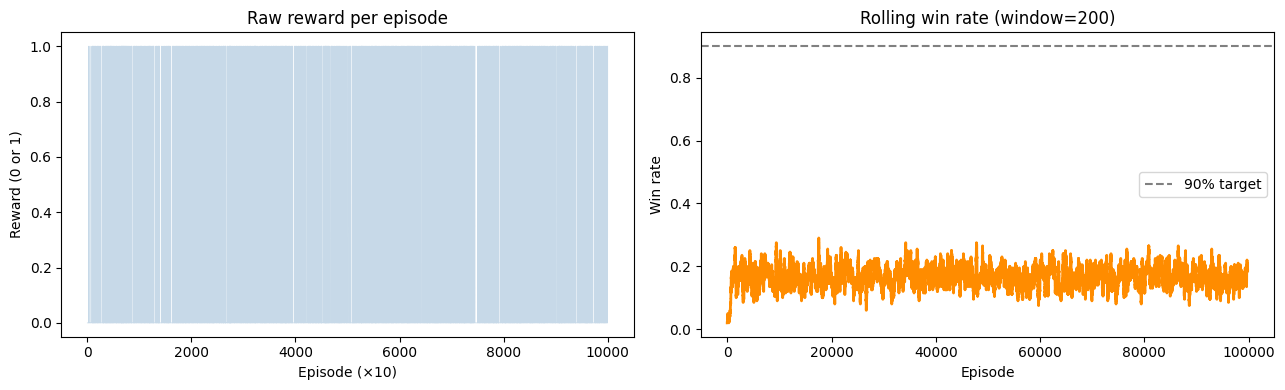

In [5]:
window = 200
rolling_avg = np.convolve(rewards_per_episode, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw rewards (sub-sampled for speed)
axes[0].plot(rewards_per_episode[::10], alpha=0.3, linewidth=0.5, color="steelblue")
axes[0].set_title("Raw reward per episode")
axes[0].set_xlabel("Episode (×10)")
axes[0].set_ylabel("Reward (0 or 1)")

# Rolling average
axes[1].plot(rolling_avg, color="darkorange", linewidth=2)
axes[1].axhline(0.9, color="gray", linestyle="--", label="90% target")
axes[1].set_title(f"Rolling win rate (window={window})")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Win rate")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6 — Inspect the Learned Q-Table

Each row is a state (0–15), each column is an action (←↓→↑).  
The highest value in each row tells us the **greedy policy**: what the trained agent will do.

In [6]:
header = f"{'State':>6}  " + "  ".join(f"{a:>6}" for a in action_names)
print("Q-table (rows=states, cols=actions):\n")
print(header)
print("-" * len(header))
for s in range(n_states):
    row = "  ".join(f"{Q[s, a]:>6.3f}" for a in range(n_actions))
    best = action_names[int(np.argmax(Q[s]))]
    print(f"{s:>6}  {row}   best={best}")

Q-table (rows=states, cols=actions):

 State       ←       ↓       →       ↑
--------------------------------------
     0   0.155   0.147   0.112   0.104   best=←
     1   0.065   0.018   0.036   0.110   best=↑
     2   0.027   0.038   0.035   0.093   best=↑
     3   0.000   0.006   0.009   0.038   best=↑
     4   0.195   0.036   0.115   0.001   best=←
     5   0.000   0.000   0.000   0.000   best=←
     6   0.019   0.000   0.004   0.007   best=←
     7   0.000   0.000   0.000   0.000   best=←
     8   0.209   0.097   0.152   0.165   best=←
     9   0.149   0.487   0.118   0.091   best=↓
    10   0.103   0.029   0.034   0.017   best=←
    11   0.000   0.000   0.000   0.000   best=←
    12   0.000   0.000   0.000   0.000   best=←
    13   0.253   0.002   0.729   0.159   best=→
    14   0.184   0.358   0.264   0.578   best=↑
    15   0.000   0.000   0.000   0.000   best=←


## 7 — Visualize the Policy on the Grid

Draw the 4×4 map and overlay the best action arrow at each non-terminal cell.

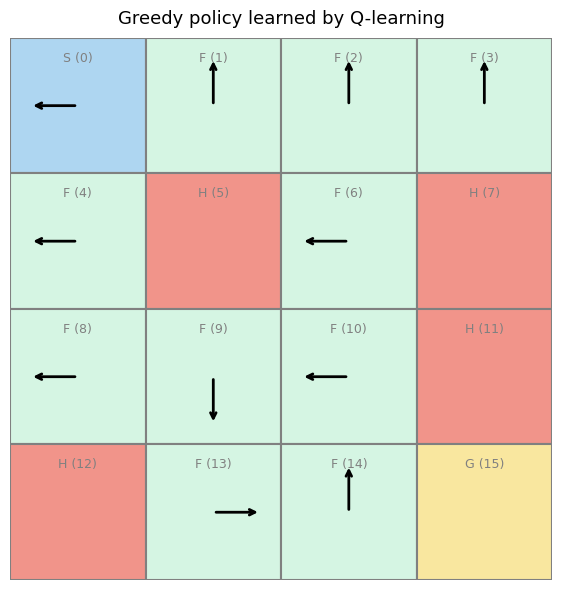

In [7]:
# FrozenLake-v1 default 4×4 map
lake_map = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG",
]

# Arrow offsets for (←↓→↑) → action indices 0,1,2,3
dx = {"←": -0.35, "↓": 0, "→": 0.35, "↑": 0}
dy = {"←": 0,     "↓": -0.35, "→": 0, "↑": 0.35}

cell_color = {"S": "#aed6f1", "F": "#d5f5e3", "H": "#f1948a", "G": "#f9e79f"}

fig, ax = plt.subplots(figsize=(6, 6))

for row in range(4):
    for col in range(4):
        state = row * 4 + col
        cell  = lake_map[row][col]
        color = cell_color[cell]

        rect = plt.Rectangle([col, 3 - row], 1, 1, color=color, ec="gray", lw=1.5)
        ax.add_patch(rect)
        ax.text(col + 0.5, 3 - row + 0.85, f"{cell} ({state})", ha="center",
                va="center", fontsize=9, color="gray")

        # Draw greedy action arrow only on non-terminal cells
        if cell not in ("H", "G"):
            best_action = action_names[int(np.argmax(Q[state]))]
            ax.annotate(
                "", xy=(col + 0.5 + dx[best_action], 3 - row + 0.5 + dy[best_action]),
                xytext=(col + 0.5, 3 - row + 0.5),
                arrowprops=dict(arrowstyle="->", color="black", lw=2),
            )

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Greedy policy learned by Q-learning", fontsize=13, pad=10)
plt.tight_layout()
plt.show()

## 8 — Watch the Agent Play One Episode

Run one greedy episode (no exploration) and print every step.

In [13]:
N_EVAL_EPISODES = 2_000

wins = 0
for _ in range(N_EVAL_EPISODES):
    state, _ = env.reset()
    for _ in range(MAX_STEPS):
        best_actions = np.flatnonzero(Q[state] == Q[state].max())
        action = int(np.random.choice(best_actions))  # greedy with random tie-break
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        if terminated or truncated:
            wins += int(reward == 1)
            break

print(f"Greedy eval win rate over {N_EVAL_EPISODES:,} episodes: {wins / N_EVAL_EPISODES:.1%}")

Greedy eval win rate over 2,000 episodes: 72.0%


## 9 — Greedy Evaluation (epsilon = 0)

Evaluate the learned Q-table without exploration to measure the true policy win rate.

In [8]:
demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
state, _ = demo_env.reset()
print(demo_env.render())

step = 0
while True:
    action = int(np.argmax(Q[state]))
    state, reward, terminated, truncated, _ = demo_env.step(action)
    step += 1
    print(f"Step {step}: action={action_names[action]}, state={state}, reward={reward}")
    print(demo_env.render())
    if terminated or truncated:
        if reward == 1:
            print("✓ Goal reached!")
        else:
            print("✗ Fell in a hole.")
        break


SFFF
FHFH
FFFH
HFFG

Step 1: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 2: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 3: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 4: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 5: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 6: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 7: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 8: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 9: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 10: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 11: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 12: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 13: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 14: action=←, state=0, reward=0.0
  (Left)
SFFF
FHFH
FFFH
HFFG

Step 15: action=←, st

## 9 — Experiments to Try

Change the hyperparameters above and re-run cells 3–8. Notice what breaks or improves.

| Experiment | What to change | What to observe |
|---|---|---|
| Too greedy | `EPSILON_DECAY = 0.01` (fast decay) | Agent stops exploring early, may get stuck |
| Slow learner | `ALPHA = 0.1` | Needs more episodes to converge |
| Short-sighted | `GAMMA = 0.5` | Agent ignores distant goal, may not reach it |
| Fewer episodes | `N_EPISODES = 500` | Q-table barely trained |
| Slippery ice | Change `is_slippery=True` | Much harder — tabular Q-learning still works but needs more episodes |

## 10 — Next Steps

1. **Discretized CartPole** — continuous states, bin them into a Q-table (see `CartPole_01.py` in this workspace)
2. **Deep Q-Network (DQN)** — replace the table with a neural network for large state spaces
3. **Double DQN** — reduces overestimation of Q-values
4. **Dueling DQN** — separate streams for state value V(s) and advantage A(s,a)